# Lab 1 Data Processing

## DPV Results

In [49]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [50]:
dpv_files = ['0_1mM.txt', '0_3mM.txt', '0_5mM.txt', '1_0mM.txt', '1_2mM.txt', '1_5mM.txt', '2_5mM.txt']
labels = ['0.1 mM', '0.3 mM', '0.5 mM', '1.0 mM', '1.2 mM', '1.5 mM', '2.5 mM']

In [51]:
dpv_data = {labels[i]: pd.read_csv('./data/'+dpv_files[i], names=['Potential', 'Current']) for i in range(len(dpv_files))}

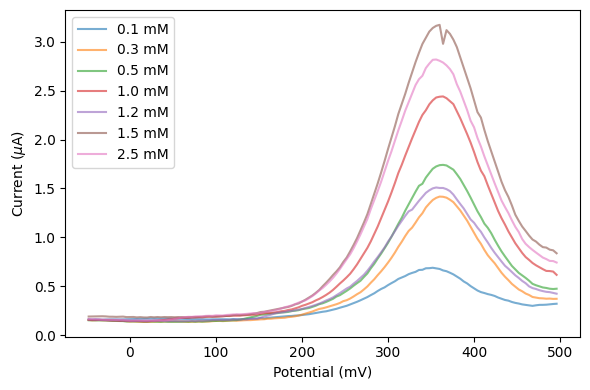

In [69]:
fig, ax = plt.subplots(figsize=(6,4))

xscale = 10**3
yscale = 10**6

for label, data in dpv_data.items(): 
    ax.plot(data['Potential']*xscale, data['Current']*yscale, label=label, alpha=0.6)

ax.legend()

ax.set_xlabel('Potential ' + r'(mV)')
ax.set_ylabel('Current ' + r'($\mu$A)')

# ax.set_title('DPV Measurements')
plt.tight_layout()
plt.show()

In [53]:
dpv_peaks = [float(v['Current'].max()) for v in dpv_data.values()]
concs = [0.1, 0.3, 0.5, 1, 1.2, 1.5, 2.5]
dpv_peaks

[6.901e-07, 1.417e-06, 1.741e-06, 2.44e-06, 1.51e-06, 3.171e-06, 2.817e-06]

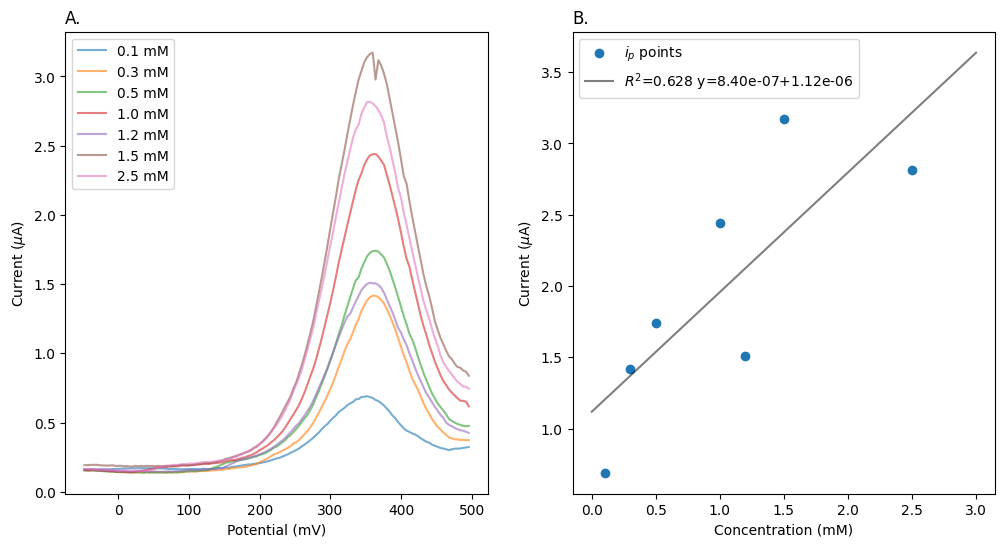

In [126]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

xscale = 10**3
yscale = 10**6

for label, data in dpv_data.items(): 
    ax[0].plot(data['Potential']*xscale, data['Current']*yscale, label=label, alpha=0.6)

ax[0].legend()

ax[0].set_xlabel('Potential ' + r'(mV)')
ax[0].set_ylabel('Current ' + r'($\mu$A)')
ax[0].set_title('A.', loc='left')

slope, intercept, r_value, p_value, std_err = stats.linregress(concs, dpv_peaks)
x = np.linspace(0, 3, 50)
y = slope * x +  intercept

ax[1].scatter(np.array(concs), np.array(dpv_peaks)*yscale, label=r'$i_p$ points')
ax[1].plot(x,y*yscale, label=r'$R^2$=' + f'{r_value**2:.3f} y={slope:.2e}+{intercept:.2e}', color='k', alpha=0.5)

ax[1].set_xlabel('Concentration ' + r'(mM)')
ax[1].set_ylabel('Current ' + r'($\mu$A)')
ax[1].set_title('B.', loc='left')

ax[1].legend()
plt.show()

In [74]:
cv_files = ['0.02.txt', '0.04.txt', '0.06.txt', '0.08.txt', '0.1.txt', '0.2.txt']
cv_labels = ['0.02 V/s', '0.04 V/s', '0.06 V/s', '0.08 V/s', '0.1 V/s', '0.2 V/s']

cv_data = {cv_labels[i]: pd.read_csv('./data/'+cv_files[i], names=['Potential', 'Current']) for i in range(len(cv_files))}

,Potential,Current
0,-0.099,2.012000e-07
1,-0.098,1.741000e-07
2,-0.097,1.655000e-07
3,-0.096,1.594000e-07
4,-0.095,1.524000e-07
...,...,...
1195,-0.096,2.320000e-07
1196,-0.097,2.336000e-07
1197,-0.098,2.350000e-07
1198,-0.099,2.366000e-07


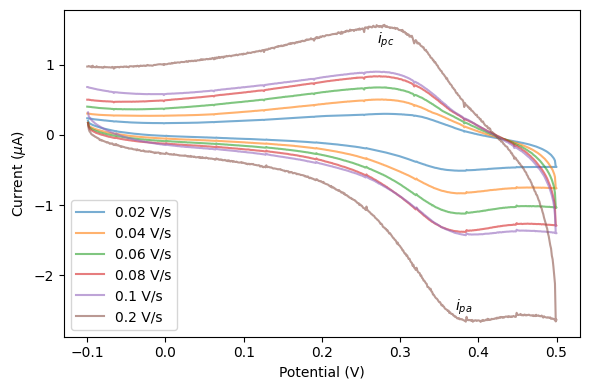

In [156]:
fig, ax = plt.subplots(figsize=(6,4))

xscale = 10**3
yscale = 10**6

for label, data in cv_data.items(): 
    ax.plot(data['Potential'], data['Current']*yscale, label=label, alpha=0.6)

ax.legend()

ax.set_xlabel('Potential ' + r'(V)')
ax.set_ylabel('Current ' + r'($\mu$A)')

ax.annotate(r'$i_{pc}$', (0.27, 1.3))
ax.annotate(r'$i_{pa}$', (0.37, -2.5))

# ax.set_title('DPV Measurements')
plt.tight_layout()
plt.show()

In [82]:
# cv_max = pd.DataFrame()
# cv_min = pd.DataFrame()
# for df in cv_data.values():
#     cv_max = pd.concat([cv_max, df.nlargest(1,'Current')])
#     cv_min = pd.concat([cv_min, df.nsmallest(1,'Current')])

In [101]:
cv_max = np.array([float(v['Current'].max()) for v in cv_data.values()])
cv_min = np.array([float(v['Current'].min()) for v in cv_data.values()])
vs = np.array([0.02, 0.04, 0.06, 0.08, 0.1, 0.2])
vssqrt = np.sqrt(vs)

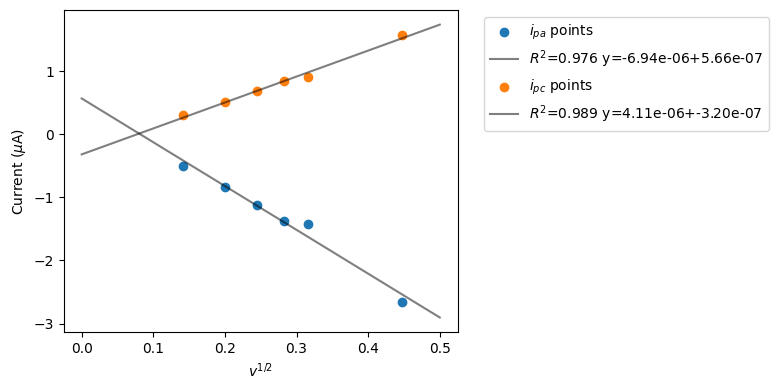

In [106]:
fig, ax = plt.subplots(figsize=(8, 4))

min_slope, min_intercept, min_r_value, min_p_value, min_std_err = stats.linregress(vssqrt, cv_min)
x = np.linspace(0, 0.5, 50)
min_y = min_slope * x +  min_intercept

ax.scatter(vssqrt, cv_min*yscale, label=r'$i_{pa}$ points')
ax.plot(x,min_y*yscale, label=r'$R^2$=' + f'{min_r_value**2:.3f} y={min_slope:.2e}+{min_intercept:.2e}', color='k', alpha=0.5)

max_slope, max_intercept, max_r_value, max_p_value, max_std_err = stats.linregress(vssqrt, cv_max)
max_y = max_slope * x +  max_intercept

ax.scatter(vssqrt, cv_max*yscale, label=r'$i_{pc}$ points')
ax.plot(x,max_y*yscale, label=r'$R^2$=' + f'{max_r_value**2:.3f} y={max_slope:.2e}+{max_intercept:.2e}', color='k', alpha=0.5)

ax.set_xlabel(r'$v^{1/2}$')
ax.set_ylabel('Current ' + r'($\mu$A)')

ax.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [113]:
vs

array([0.02, 0.04, 0.06, 0.08, 0.1 , 0.2 ])

In [115]:
cv_max

array([3.015e-07, 5.054e-07, 6.779e-07, 8.373e-07, 9.020e-07, 1.568e-06])

In [114]:
cv_min

array([-5.098e-07, -8.315e-07, -1.120e-06, -1.381e-06, -1.428e-06,
       -2.661e-06])

In [112]:
def diffusion_co(ip, v): 
    return (ip/((2.69*10**5)*(1**1.5)*0.0314*(10**-7)*v)) ** 2

d_ipa = [diffusion_co(cv_min[i], vssqrt[i]) for i in range(len(cv_min))]
d_ipc = [diffusion_co(cv_max[i], vssqrt[i]) for i in range(len(cv_max))]

print(d_ipa)
print(d_ipc)

[np.float64(1.8214020055857124e-05), np.float64(2.4227056918535928e-05), np.float64(2.9303597389770647e-05), np.float64(3.341438821436884e-05), np.float64(2.858199630404754e-05), np.float64(4.962447181109027e-05)]
[np.float64(6.37060651105934e-06), np.float64(8.950486208044448e-06), np.float64(1.073534884227459e-05), np.float64(1.2283109947198145e-05), np.float64(1.1403790202825392e-05), np.float64(1.7230515265185136e-05)]


In [117]:
np.mean(d_ipc)

np.float64(1.1162309496097844e-05)